# 读取数据

In [1]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.cluster import KMeans
from scipy.ndimage import correlate
import warnings
warnings.filterwarnings("ignore", category=UserWarning) # 屏蔽单维 KMeans 的内存警告

In [2]:
import polars as pl

# Polars 原生支持 parquet，性能极高
try:
    df_total = pl.read_parquet("epv_events.parquet.gzip")
    print(df_total.head())
except Exception as e:
    print(f"读取失败: {e}")

shape: (5, 23)
┌───────┬────────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ index ┆ _id        ┆ match_id   ┆ event_type ┆ … ┆ stat_poss ┆ destinati ┆ opponent_ ┆ stat_play │
│ ---   ┆ ---        ┆ ---        ┆ ---        ┆   ┆ team_arra ┆ on_player ┆ team      ┆ er_id_arr │
│ i64   ┆ str        ┆ str        ┆ str        ┆   ┆ y         ┆ ---       ┆ ---       ┆ ay        │
│       ┆            ┆            ┆            ┆   ┆ ---       ┆ f64       ┆ f64       ┆ ---       │
│       ┆            ┆            ┆            ┆   ┆ binary    ┆           ┆           ┆ binary    │
╞═══════╪════════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0     ┆ 6839d295b7 ┆ 68397b9914 ┆ Mantener   ┆ … ┆ b"[false, ┆ null      ┆ 181.0     ┆ b"[80906, │
│       ┆ 91492b0852 ┆ ffd9f06b06 ┆ el Balon   ┆   ┆ false,fal ┆           ┆           ┆ 105571,15 │
│       ┆ 563c       ┆ a136       ┆            ┆   ┆ se,false, ┆           ┆

In [3]:
import polars as pl

# Polars 1.0+ 推荐使用 len()，如果是极老的版本请用 count()
result = df_total.group_by("event_type").len()

# 如果需要按数量降序排列：
result_sorted = df_total.group_by("event_type").len().sort("len", descending=True)
print(result_sorted)

shape: (3, 2)
┌───────────────────┬────────┐
│ event_type        ┆ len    │
│ ---               ┆ ---    │
│ str               ┆ u32    │
╞═══════════════════╪════════╡
│ Pase              ┆ 360708 │
│ Mantener el Balon ┆ 273403 │
│ Remate            ┆ 9028   │
└───────────────────┴────────┘


In [11]:
import polars as pl

# 1. 过滤出 Remate -> 2. 按 team 分组 -> 3. 统计数量 -> 4. 降序排列
result = (
    df_total.filter(
        pl.col("event_type") == "Remate"  # 💡 注意这里的两对括号
    )
    .group_by("team")
    .len()  # Polars 1.0+ 推荐写法，生成名为 "len" 的列
    .sort("len", descending=True)
)

print(result)

shape: (20, 2)
┌──────┬─────┐
│ team ┆ len │
│ ---  ┆ --- │
│ i64  ┆ u32 │
╞══════╪═════╡
│ 178  ┆ 679 │
│ 186  ┆ 633 │
│ 449  ┆ 539 │
│ 184  ┆ 518 │
│ 185  ┆ 513 │
│ …    ┆ …   │
│ 181  ┆ 388 │
│ 191  ┆ 388 │
│ 177  ┆ 358 │
│ 957  ┆ 353 │
│ 192  ┆ 336 │
└──────┴─────┘


In [3]:
df_total.head()


index,_id,match_id,event_type,start_frame,end_frame,origin_player,team,success,norm_origin_pos_x,norm_origin_pos_y,norm_destination_pos_x,norm_destination_pos_y,stat_full_minute,stat_half,stat_posx_array,stat_posy_array,stat_velx_array,stat_vely_array,stat_possteam_array,destination_player,opponent_team,stat_player_id_array
i64,str,str,str,i64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,binary,binary,binary,binary,binary,f64,f64,binary
0,"""6839d295b791492b0852563c""","""68397b9914ffd9f06b06a136""","""Mantener el Balon""",1782534,1782559,88952,407,"""Fallido""",0.39221,0.21352,0.42538,0.20223,58.0,2.0,"b""[0.36805999999999994,0.59049,0.59078,0.4027599999999999,0.48""…","b""[0.36700999999999995,0.4849899999999999,0.69896,0.4964299999""…","b""[0.03536000000000006,0.017020000000000035,0.0118800000000000""…","b""[-0.03922000000000003,-0.011289999999999911,-0.0169400000000""…","b""[false,false,false,false,false,false,false,false,false,false""…",null,181.0,"b""[80906,105571,152723,156293,169007,170116,212873,227164,4374""…"
1,"""6839d295b13a38a4c952563c""","""68397b9914ffd9f06b06a136""","""Mantener el Balon""",1699658,1699683,88952,407,"""Fallido""",0.77937,0.30743,0.77101,0.22883,20.0,1.0,"b""[0.63099,0.8758600000000001,0.8510500000000001,0.52899000000""…","b""[0.51263,0.45765000000000006,0.51961,0.50654,0.3689500000000""…","b""[0.006650000000000045,-0.016349999999999976,-0.0084600000000""…","b""[-0.03223999999999999,-0.004310000000000036,-0.0005899999999""…","b""[false,false,false,false,false,false,false,false,false,false""…",null,181.0,"b""[80906,105571,152723,156293,169007,170116,212873,227164,4374""…"
2,"""6839d295b791492b0852563d""","""68397b9914ffd9f06b06a136""","""Mantener el Balon""",1782559,1782584,88952,407,"""Fallido""",0.42538,0.20223,0.46825,0.19435,58.0,2.0,"b""[0.40342,0.60751,0.60266,0.42072,0.5109299999999999,0.61968,""…","b""[0.3277899999999999,0.4737,0.68202,0.4933099999999999,0.6857""…","b""[0.040690000000000004,0.019870000000000054,0.018159999999999""…","b""[-0.03045999999999993,-0.01426000000000005,-0.02005999999999""…","b""[false,false,false,false,false,false,false,false,false,false""…",null,181.0,"b""[80906,105571,152723,156293,169007,170116,212873,227164,4374""…"
3,"""6839d295b13a38a4c952563d""","""68397b9914ffd9f06b06a136""","""Mantener el Balon""",1699683,1699708,88952,407,"""Fallido""",0.77101,0.22883,0.79373,0.15423,20.0,1.0,"b""[0.6376400000000001,0.8595100000000001,0.8425900000000001,0.""…","b""[0.48039000000000004,0.45334,0.51902,0.46107000000000004,0.3""…","b""[0.016349999999999976,0.005979999999999985,0.013109999999999""…","b""[-0.01917000000000002,0.02124999999999999,0.0020799999999999""…","b""[false,false,false,false,false,false,false,false,false,false""…",null,181.0,"b""[80906,105571,152723,156293,169007,170116,212873,227164,4374""…"
4,"""6839d295b13a38a4c952563e""","""68397b9914ffd9f06b06a136""","""Mantener el Balon""",1699708,1699733,88952,407,"""Fallido""",0.79373,0.15423,0.82538,0.13314,20.0,1.0,"b""[0.6539900000000001,0.8654900000000001,0.8557,0.533940000000""…","b""[0.46122,0.47459,0.5211,0.43819,0.33180000000000004,0.320650""…","b""[0.02071999999999996,0.019869999999999943,0.0214900000000000""…","b""[-0.01158999999999999,0.0050500000000000544,0.01263000000000""…","b""[false,false,false,false,false,false,false,false,false,false""…",null,181.0,"b""[80906,105571,152723,156293,169007,170116,212873,227164,4374""…"


In [6]:
df_total.shape

(643139, 23)

In [4]:
# 返回一个 Polars Series
unique_matches = df_total['match_id'].unique()

# 转换为列表
match_id_list = df_total['match_id'].unique().to_list()
print(match_id_list)
# 统计独特 match_id 的数量
match_count = df_total.select(pl.col('match_id').n_unique()).item()
print(f"总比赛场数: {match_count}")

['683da6b54fe78cbe3a2580ea', '683d94124fe78cbe3af61d03', '683dc8584fe78cbe3a7d131c', '683e1c094fe78cbe3a5b0903', '683e442e4fe78cbe3ac50af5', '683db9d84fe78cbe3a574cc1', '683dbf5a4fe78cbe3a659923', '683db5054fe78cbe3a4b6ae8', '683df6dd4fe78cbe3af80305', '683a11087773b55f2b2efdf9', '683d9ac74fe78cbe3a06bb38', '683e96cf4fe78cbe3aa11c30', '683a19fe7773b55f2b46f1c0', '683e25b04fe78cbe3a74b810', '683a1bc47773b55f2b4bb51d', '683e222e4fe78cbe3a6b658e', '683a0f427773b55f2b2a3661', '683df27f4fe78cbe3aec6e18', '683e8bf84fe78cbe3a84234b', '683a2a2d7773b55f2b71aafb', '683e67bd4fe78cbe3a23b341', '683e79584fe78cbe3a527981', '683a2ce07773b55f2b78e2e1', '683de6f94fe78cbe3acda35a', '683d99db4fe78cbe3a047042', '683dde034fe78cbe3ab5d5de', '683e376c4fe78cbe3aa3aab0', '683e3cc44fe78cbe3ab1b620', '683e3a0b4fe78cbe3aaab07e', '683a182b7773b55f2b41f8da', '683d95144fe78cbe3af87c5a', '683e2da24fe78cbe3a89e1df', '683e535c4fe78cbe3aed37e4', '683e04234fe78cbe3a1b43f6', '683d8b604fe78cbe3ae1298d', '683a475d1ffcc57e43

In [5]:

# 1. 一键切分为字典，并通过 lambda 表达式在切分的同时完成内部排序
match_dict = {
    match_id: sub_df.sort("start_frame")
    for match_id, sub_df in df_total.partition_by("match_id", as_dict=True).items()
}


# 2. 随时通过具体的 match_id 获取对应比赛按时间排好序的事件链

# 陷阱：Polars 的 as_dict=True 默认生成的 Key 是一个元组，如 ('68397b9914ffd9f06b06a136',)
target_match = ("68397b9914ffd9f06b06a136",)

if target_match in match_dict:
    game_df = match_dict[target_match]
    print("成功通过元组 Key 找到比赛！")
if target_match in match_dict:
    game_df = match_dict[target_match]
    print(f"成功获取比赛 {target_match}，其前5个事件：")
    # 临时将显示列数、行数、列宽、字符长度都设为无限制（或极大值）
    with pl.Config(
        tbl_cols=-1,       # -1 代表显示所有列，不再出现中间的 ...
        tbl_rows=20,       # 显式输出的行数（默认是 8 行）
        tbl_width_chars=1000, # 允许单行最宽的字符数，防止列换行错位
        fmt_str_lengths=100,  # 允许字符串/二进制内容显示的最大长度，防止出现 fal...
        ):
        print(game_df.head(5))
else:
    print(f"未在数据集中找到 match_id 为 {target_match} 的比赛。")

成功通过元组 Key 找到比赛！
成功获取比赛 ('68397b9914ffd9f06b06a136',)，其前5个事件：
shape: (5, 23)
┌───────┬──────────────────────────┬──────────────────────────┬────────────┬─────────────┬───────────┬───────────────┬──────┬─────────┬───────────────────┬───────────────────┬────────────────────────┬────────────────────────┬──────────────────┬───────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────┬───────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ ind

In [6]:
import random
import polars as pl

# ==============================================================================
# 构建 10 场比赛的微型测试集 (Test Sandbox)
# ==============================================================================

# 获取所有比赛的 keys (注意：Polars partition_by as_dict=True 的 key 是 tuple 形式)
all_match_keys = list(match_dict.keys())

# 设定固定的随机种子，保证每次运行 Notebook 抽取的都是这 10 场比赛
# 这对于我们在开发过程中对比代码修改前后 (如 5x5网格 vs 1x1网格) 的结果至关重要
random.seed(42) 

# 策略 A：科学随机抽样 10 场比赛（推荐，能覆盖不同球队的战术与阵型特征）
sampled_keys = random.sample(all_match_keys, 30)

# 策略 B：如果你想专门研究某几场特定的焦点战，可以直接在这里硬编码 match_id 元组
# sampled_keys = [('68397b9914ffd9f06b06a136',), ('另一种特定的match_id',), ...]

print("🎯 成功抽取 10 场测试比赛 ID:")
for i, k in enumerate(sampled_keys):
    print(f"  {i+1}. {k[0]}")

# 将这 10 场比赛的数据块重新垂直拼接 (Concat) 成一个新的测试 DataFrame
df = pl.concat([match_dict[k] for k in sampled_keys])

print(f"\n📊 测试集数据规模: {df.shape[0]} 行")

# 确保时间序列严格排序，防止拼接后出现帧数跳跃
df = df.sort(["match_id", "team", "start_frame"])

# ==============================================================================
# 现在，你可以安全地将 test_df 送入方案一的 PC 算力引擎中进行小规模验证了
# df_result = test_df.with_columns(...)
# ==============================================================================

🎯 成功抽取 10 场测试比赛 ID:
  1. 683e71644fe78cbe3a3d71c3
  2. 683a49441ffcc57e43702c17
  3. 683a13af7773b55f2b35fc9e
  4. 683dcb084fe78cbe3a842503
  5. 683dbd814fe78cbe3a60d5e0
  6. 683db33f4fe78cbe3a46bc8c
  7. 683d8b604fe78cbe3ae1298d
  8. 683e9dea4fe78cbe3ab3d44c
  9. 683a44981ffcc57e43644231
  10. 683e82404fe78cbe3a6a42c5
  11. 683e46d34fe78cbe3acc203b
  12. 683a305c7773b55f2b823ea1
  13. 683e5b474fe78cbe3a02652e
  14. 683e0ec54fe78cbe3a37ab86
  15. 683a173b7773b55f2b3f737e
  16. 683a165c7773b55f2b3d26f2
  17. 683a33037773b55f2b894929
  18. 683db0924fe78cbe3a3fa6e7
  19. 683db7e84fe78cbe3a527ea2
  20. 683e33d54fe78cbe3a9a2742
  21. 683e60a94fe78cbe3a10cb54
  22. 683a149b7773b55f2b387bc4
  23. 683e4e0d4fe78cbe3adf078a
  24. 683da7984fe78cbe3a27d94e
  25. 683e94294fe78cbe3a9a00d6
  26. 683e75d44fe78cbe3a49257a
  27. 683e8dc94fe78cbe3a88f376
  28. 683e0cff4fe78cbe3a32e543
  29. 683db1774fe78cbe3a41fa8b
  30. 683e1a444fe78cbe3a5646a4

📊 测试集数据规模: 51141 行


# 每次读取10场并处理，直至读完

In [7]:
import os
import gc
import json
import numpy as np
import polars as pl
from scipy.spatial import ConvexHull, Delaunay

# ==============================================================================
# 1. 全局配置、物理常量与底图矩阵
# ==============================================================================
OUTPUT_DIR = "./processed_data_light"  # 建议更换新目录存放轻量级数据
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 物理与球场常量
PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0
GOAL_X = 105.0
GOAL_Y_CENTER = 34.0
GOAL_POST_TOP = 37.66
GOAL_POST_BOT = 30.34
GOAL_WIDTH = 7.32

# 动力学参数
MAX_SPEED = 5.0
MAX_ACCEL = 7.0
LAMBDA_ATT = 3.99
KAPPA = 1.72
LAMBDA_DEF = LAMBDA_ATT * KAPPA
S_PARAM = 0.54  

# 保留底层 Pitch Control 必需的坐标网格
x_bins = np.arange(0, int(PITCH_LENGTH), 1)
y_bins = np.arange(0, int(PITCH_WIDTH), 1)
X_GRID, Y_GRID = np.meshgrid(x_bins, y_bins)

# Karun Singh 12x8 xT 权重矩阵
XT_MATRIX = np.array([
    [0.003, 0.004, 0.003, 0.004, 0.004, 0.005, 0.007, 0.008, 0.01, 0.013, 0.018, 0.025, 0.037, 0.048, 0.062, 0.066],
    [0.003, 0.005, 0.004, 0.004, 0.004, 0.005, 0.007, 0.008, 0.011, 0.015, 0.020, 0.029, 0.042, 0.056, 0.075, 0.092],
    [0.003, 0.003, 0.003, 0.004, 0.004, 0.006, 0.007, 0.009, 0.012, 0.016, 0.023, 0.034, 0.046, 0.067, 0.094, 0.103],
    [0.004, 0.004, 0.004, 0.004, 0.004, 0.006, 0.007, 0.009, 0.012, 0.016, 0.023, 0.034, 0.044, 0.068, 0.089, 0.123],
    [0.005, 0.005, 0.006, 0.004, 0.004, 0.006, 0.007, 0.01, 0.013, 0.017, 0.025, 0.033, 0.0480, 0.068, 0.126, 0.158],
    [0.004, 0.005, 0.007, 0.004, 0.004, 0.006, 0.008, 0.009, 0.013, 0.017, 0.025, 0.033, 0.052, 0.089, 0.171, 0.413],
    [0.004, 0.005, 0.007, 0.005, 0.005, 0.005, 0.008, 0.01, 0.012, 0.019, 0.025, 0.035, 0.042, 0.116, 0.176, 0.371],
    [0.005, 0.006, 0.007, 0.005, 0.005, 0.006, 0.008, 0.009, 0.014, 0.018, 0.024, 0.037, 0.046, 0.077, 0.124, 0.158],
    [0.004, 0.005, 0.005, 0.004, 0.004, 0.006, 0.008, 0.009, 0.013, 0.017, 0.024, 0.036, 0.047, 0.06, 0.096, 0.126],
    [0.003, 0.004, 0.004, 0.004, 0.005, 0.006, 0.008, 0.01, 0.013, 0.016, 0.024, 0.036, 0.049, 0.068, 0.096, 0.136],
    [0.003, 0.003, 0.004, 0.004, 0.005, 0.006, 0.008, 0.01, 0.012, 0.015, 0.022, 0.031, 0.044, 0.060, 0.077, 0.096],
    [0.002, 0.003, 0.004, 0.004, 0.005, 0.006, 0.007, 0.008, 0.011, 0.014, 0.019, 0.026, 0.039, 0.051, 0.063, 0.068]
])

# ==============================================================================
# 2. 精简版 Polars Schema
# ==============================================================================
# 注意：start_xT, current_threat, defensive_hull_area, is_ball_inside_def_hull
# 是在 DataFrame 层级解算的，不在此字典中定义，但最终会汇聚到一起。
PC_DTYPE = pl.Struct([
    pl.Field("pc_5m_lf", pl.Float64), pl.Field("pc_5m_rf", pl.Float64),
    pl.Field("pc_5m_lb", pl.Float64), pl.Field("pc_5m_rb", pl.Float64),
    pl.Field("pc_15m_lf", pl.Float64), pl.Field("pc_15m_rf", pl.Float64),
    pl.Field("pc_15m_lb", pl.Float64), pl.Field("pc_15m_rb", pl.Float64),
    pl.Field("pass_length", pl.Float64),
    pl.Field("dest_pc_5m", pl.Float64),
    pl.Field("pos_formation_height", pl.Float64), pl.Field("pos_formation_width", pl.Float64),
    pl.Field("def_formation_height", pl.Float64), pl.Field("def_formation_width", pl.Float64),
    pl.Field("pos_space_0_area", pl.Float64), pl.Field("pos_space_1_area", pl.Float64),
    pl.Field("pos_space_2_area", pl.Float64), pl.Field("pos_space_3_area", pl.Float64),
    pl.Field("def_space_0_area", pl.Float64), pl.Field("def_space_1_area", pl.Float64),
    pl.Field("def_space_2_area", pl.Float64), pl.Field("def_space_3_area", pl.Float64),
    pl.Field("pc_in_def_space_0", pl.Float64), pl.Field("pc_in_def_space_1", pl.Float64),
    pl.Field("pc_in_def_space_2", pl.Float64), pl.Field("pc_in_def_space_3", pl.Float64),
    pl.Field("pc_ratio_def_space_0", pl.Float64), pl.Field("pc_ratio_def_space_1", pl.Float64),
    pl.Field("pc_ratio_def_space_2", pl.Float64), pl.Field("pc_ratio_def_space_3", pl.Float64),
    pl.Field("dist_to_goal", pl.Float64), pl.Field("angle_to_goal", pl.Float64),
    pl.Field("path_pc_min_1", pl.Float64), pl.Field("path_pc_min_2", pl.Float64), pl.Field("path_pc_min_3", pl.Float64)
])

GLOBAL_EMPTY_RES = {f.name: 0.0 for f in PC_DTYPE.fields}

HULL_DTYPE = pl.Struct([
    pl.Field("defensive_hull_area", pl.Float64),
    pl.Field("is_ball_inside_def_hull", pl.Boolean)
])

# ==============================================================================
# 3. 核心计算与功能函数
# ==============================================================================
def calculate_xt(x, y):
    col = min(max(0, int(x * 16)), 15)
    row = min(max(0, int(y * 12)), 11)
    return XT_MATRIX[row, col]

def calculate_current_threat_polars(df, n_steps=5, threshold=50, alpha=0.87):
    step_xt_cols = []
    is_continuous = pl.lit(True)
    
    for i in range(1, n_steps + 1):
        current_start = pl.col('start_frame').shift(-i)
        prev_end = pl.col('end_frame').shift(-(i - 1))
        current_xt = pl.col('start_xT').shift(-i)
        
        gap = current_start - prev_end
        is_continuous = is_continuous & (gap >= 0) & (gap <= threshold)
        
        step_xt = pl.when(is_continuous & current_xt.is_not_null()) \
                    .then(current_xt * (alpha ** i)) \
                    .otherwise(0.0)
        step_xt_cols.append(step_xt)
    
    return df.with_columns(
        pl.max_horizontal(step_xt_cols).alias('current_threat')
    )

def calculate_defensive_hull_features(struct_row) -> dict:
    empty_res = {"defensive_hull_area": 0.0, "is_ball_inside_def_hull": False}
    try:
        bx_norm = struct_row.get("norm_origin_pos_x")
        by_norm = struct_row.get("norm_origin_pos_y")
        
        if bx_norm is None or np.isnan(bx_norm) or by_norm is None or np.isnan(by_norm):
            return empty_res
            
        bx, by = float(bx_norm) * PITCH_LENGTH, float(by_norm) * PITCH_WIDTH

        px = json.loads(struct_row["stat_posx_array"].decode('utf-8'))
        py = json.loads(struct_row["stat_posy_array"].decode('utf-8'))
        is_teammate = json.loads(struct_row["stat_possteam_array"].decode('utf-8'))
        
        if "stat_is_gk_array" in struct_row and struct_row["stat_is_gk_array"] is not None:
            is_gk = json.loads(struct_row["stat_is_gk_array"].decode('utf-8'))
        else:
            is_gk = [False] * len(px)
        
        def_x, def_y = [], []
        for i in range(len(px)):
            if px[i] is None or py[i] is None: continue
            if not is_teammate[i] and not is_gk[i]:
                def_x.append(px[i] * PITCH_LENGTH)
                def_y.append(py[i] * PITCH_WIDTH)
                
        if len(def_x) < 3:
            return empty_res
            
        pts = np.column_stack((def_x, def_y))
        hull = ConvexHull(pts)
        area = hull.volume  
        
        hull_delaunay = Delaunay(pts[hull.vertices])
        is_inside = hull_delaunay.find_simplex((bx, by)) >= 0
        
        return {"defensive_hull_area": float(area), "is_ball_inside_def_hull": bool(is_inside)}
    except Exception:
        return empty_res

def get_longitudinal_spaces_fast(px_array, x_grid, n_lines=3):
    if len(px_array) < n_lines:
        return np.zeros_like(x_grid, dtype=np.int8)
    
    px_sorted = np.sort(px_array)
    if len(px_sorted) >= 11:
        if px_sorted[0] < (PITCH_LENGTH - px_sorted[-1]):
            outfield_x = px_sorted[1:]  
        else:
            outfield_x = px_sorted[:-1] 
    else:
        outfield_x = px_sorted
        
    gaps = np.diff(outfield_x)
    cut_indices = np.argsort(gaps)[-(n_lines - 1):]
    cut_indices = np.sort(cut_indices) + 1  
    
    splits = np.split(outfield_x, cut_indices)
    lines = np.array([np.mean(s) for s in splits if len(s) > 0])
    
    if len(lines) < n_lines:
        lines = np.linspace(outfield_x[0], outfield_x[-1], n_lines)
    else:
        lines = np.sort(lines)
    
    return np.digitize(x_grid, bins=lines).astype(np.int8)

def compute_dense_pc_and_rings(bx, by, dest_x, dest_y, att_pos, att_vel, def_pos, def_vel):
    N_att, N_def = len(att_pos), len(def_pos)
    N = N_att + N_def
    
    if N_att == 0 or N_def == 0:
        return GLOBAL_EMPTY_RES
        
    pos = np.vstack([att_pos, def_pos])  
    vel = np.vstack([att_vel, def_vel])  
    
    lam = np.empty(N)
    lam[:N_att] = LAMBDA_ATT
    lam[N_att:] = LAMBDA_DEF
    
    px = pos[:, 0].reshape(-1, 1, 1)
    py = pos[:, 1].reshape(-1, 1, 1)
    vx = vel[:, 0].reshape(-1, 1, 1)
    vy = vel[:, 1].reshape(-1, 1, 1)
    lam = lam.reshape(-1, 1, 1)

    dx = X_GRID[None, :, :] - px  
    dy = Y_GRID[None, :, :] - py
    dist = np.hypot(dx, dy)
    dist_safe = np.where(dist == 0, 1e-5, dist)
    
    v_proj = (vx * dx + vy * dy) / dist_safe
    v_proj = np.clip(v_proj, -MAX_SPEED, MAX_SPEED)
    
    t_acc = (MAX_SPEED - v_proj) / MAX_ACCEL
    d_acc = v_proj * t_acc + 0.5 * MAX_ACCEL * (t_acc ** 2)
    
    tau = np.where(
        dist < d_acc,
        (-v_proj + np.sqrt(np.clip(v_proj**2 + 2.0 * MAX_ACCEL * dist, 0, None))) / MAX_ACCEL,
        t_acc + (dist - d_acc) / MAX_SPEED
    )
    tau = np.clip(tau, 0, None)  
    tau_min = np.min(tau, axis=0) 
    delta_tau = tau - tau_min[None, :, :] 
    
    active_mask = delta_tau <= 1.2 
    weights = lam * np.exp(-delta_tau / S_PARAM) * active_mask
    
    sum_weights = np.sum(weights, axis=0)
    sum_weights_safe = np.where(sum_weights == 0, 1.0, sum_weights)
    ppcf = weights / sum_weights_safe  
    att_ppcf = np.sum(ppcf[:N_att], axis=0)          

    # 计算阵型宽高
    def calc_formation_dims(pos_array):
        if len(pos_array) < 2: return 0.0, 0.0
        p_x, p_y = pos_array[:, 0], pos_array[:, 1]
        px_sorted = np.sort(p_x)
        if len(px_sorted) >= 11:
            gk_x = px_sorted[0] if px_sorted[0] < (PITCH_LENGTH - px_sorted[-1]) else px_sorted[-1]
            mask = p_x != gk_x
            outfield_x, outfield_y = p_x[mask], p_y[mask]
        else:
            outfield_x, outfield_y = p_x, p_y
        if len(outfield_x) < 2: return 0.0, 0.0
        return float(np.ptp(outfield_x)), float(np.ptp(outfield_y))

    pos_height, pos_width = calc_formation_dims(att_pos)
    def_height, def_width = calc_formation_dims(def_pos)

    # 阵型空间切分与面积
    pos_space_matrix = get_longitudinal_spaces_fast(att_pos[:, 0], X_GRID, n_lines=3)
    def_space_matrix = get_longitudinal_spaces_fast(def_pos[:, 0], X_GRID, n_lines=3)
    
    pos_areas = [float(np.sum(pos_space_matrix == i)) for i in range(4)]
    def_areas = [float(np.sum(def_space_matrix == i)) for i in range(4)]
    
    total_att_pc = float(np.sum(att_ppcf))
    pc_in_def_spaces = [float(np.sum(att_ppcf[def_space_matrix == i])) for i in range(4)]
    pc_ratio_def_spaces = [(val / total_att_pc) if total_att_pc > 0 else 0.0 for val in pc_in_def_spaces]
    
    # 起点扇区掩膜计算
    dx_ball = X_GRID - bx
    dy_ball = Y_GRID - by
    dist_to_ball = np.hypot(dx_ball, dy_ball)
    mask_0_5 = dist_to_ball <= 5.0
    mask_5_15 = (dist_to_ball > 5.0) & (dist_to_ball <= 15.0)
    mask_lf = (dx_ball >= 0) & (dy_ball >= 0)
    mask_rf = (dx_ball >= 0) & (dy_ball < 0)
    mask_lb = (dx_ball < 0) & (dy_ball >= 0)
    mask_rb = (dx_ball < 0) & (dy_ball < 0)
    
    def get_mean_pc(dist_mask, quad_mask):
        valid_cells = att_ppcf[dist_mask & quad_mask]
        return float(np.mean(valid_cells)) if len(valid_cells) > 0 else 0.0
    
    # 动态几何与传球目标计算
    if bx is not None and by is not None and not np.isnan(by):
        d_dist = float(np.hypot(GOAL_X - bx, GOAL_Y_CENTER - by))
        d_num = GOAL_WIDTH * (GOAL_X - bx)
        d_den = (GOAL_X - bx)**2 + (by - GOAL_POST_TOP) * (by - GOAL_POST_BOT)
        d_angle = float(np.abs(np.arctan2(d_num, d_den)))
        if bx >= GOAL_X: d_angle = 0.0
    else:
        d_dist, d_angle = 0.0, 0.0
    
    att_ppcf_2d = att_ppcf.reshape((len(y_bins), len(x_bins)))
    
    # 路径脆弱性计算 (仅对真实传球终点)
    if dest_x is not None and dest_y is not None and not np.isnan(dest_x) and not np.isnan(dest_y):
        pass_length = float(np.hypot(dest_x - bx, dest_y - by))
        
        # Dest PC 5m
        dx_dest = X_GRID - dest_x
        dy_dest = Y_GRID - dest_y
        mask_dest_5m = np.hypot(dx_dest, dy_dest) <= 5.0
        valid_dest_cells = att_ppcf[mask_dest_5m]
        dest_pc_5m = float(np.mean(valid_dest_cells)) if len(valid_dest_cells) > 0 else 0.0

        # Path Vulnerability
        dist_to_dest = pass_length
        n_pts = max(5, int(dist_to_dest * 2)) 
        t_path = np.linspace(0, 1, n_pts)
        px_path = np.clip(np.round(bx + t_path * (dest_x - bx)).astype(int), 0, 104)
        py_path = np.clip(np.round(by + t_path * (dest_y - by)).astype(int), 0, 67)
        path_pc = att_ppcf_2d[py_path, px_path]
        path_pc_sorted = np.sort(path_pc)
        if len(path_pc_sorted) >= 3:
            pc_min_1, pc_min_2, pc_min_3 = float(path_pc_sorted[0]), float(path_pc_sorted[1]), float(path_pc_sorted[2])
        else:
            pc_min_1 = pc_min_2 = pc_min_3 = float(path_pc_sorted[0])
    else:
        pass_length = 0.0
        dest_pc_5m = 0.0
        pc_min_1 = pc_min_2 = pc_min_3 = 0.0

    return {
        "pc_5m_lf": get_mean_pc(mask_0_5, mask_lf), "pc_5m_rf": get_mean_pc(mask_0_5, mask_rf),
        "pc_5m_lb": get_mean_pc(mask_0_5, mask_lb), "pc_5m_rb": get_mean_pc(mask_0_5, mask_rb),
        "pc_15m_lf": get_mean_pc(mask_5_15, mask_lf), "pc_15m_rf": get_mean_pc(mask_5_15, mask_rf),
        "pc_15m_lb": get_mean_pc(mask_5_15, mask_lb), "pc_15m_rb": get_mean_pc(mask_5_15, mask_rb),
        "pass_length": pass_length,
        "dest_pc_5m": dest_pc_5m,
        "pos_formation_height": pos_height, "pos_formation_width": pos_width,
        "def_formation_height": def_height, "def_formation_width": def_width,
        "pos_space_0_area": pos_areas[0], "pos_space_1_area": pos_areas[1],
        "pos_space_2_area": pos_areas[2], "pos_space_3_area": pos_areas[3],
        "def_space_0_area": def_areas[0], "def_space_1_area": def_areas[1],
        "def_space_2_area": def_areas[2], "def_space_3_area": def_areas[3],
        "pc_in_def_space_0": pc_in_def_spaces[0], "pc_in_def_space_1": pc_in_def_spaces[1],
        "pc_in_def_space_2": pc_in_def_spaces[2], "pc_in_def_space_3": pc_in_def_spaces[3],
        "pc_ratio_def_space_0": pc_ratio_def_spaces[0], "pc_ratio_def_space_1": pc_ratio_def_spaces[1],
        "pc_ratio_def_space_2": pc_ratio_def_spaces[2], "pc_ratio_def_space_3": pc_ratio_def_spaces[3],
        "dist_to_goal": d_dist,
        "angle_to_goal": d_angle,
        "path_pc_min_1": pc_min_1, "path_pc_min_2": pc_min_2, "path_pc_min_3": pc_min_3
    }

def apply_unified_pc_calculation(struct_row) -> dict:
    bx_norm = struct_row["norm_origin_pos_x"]
    by_norm = struct_row["norm_origin_pos_y"]
    dest_x_norm = struct_row.get("norm_destination_pos_x")
    dest_y_norm = struct_row.get("norm_destination_pos_y")
    
    if bx_norm is None or np.isnan(bx_norm) or by_norm is None or np.isnan(by_norm):
        return GLOBAL_EMPTY_RES

    dest_x = dest_x_norm * PITCH_LENGTH if dest_x_norm is not None else None
    dest_y = dest_y_norm * PITCH_WIDTH if dest_y_norm is not None else None
    bx, by = bx_norm * PITCH_LENGTH, by_norm * PITCH_WIDTH

    try:
        px = json.loads(struct_row["stat_posx_array"].decode('utf-8'))
        py = json.loads(struct_row["stat_posy_array"].decode('utf-8'))
        vx = json.loads(struct_row["stat_velx_array"].decode('utf-8'))
        vy = json.loads(struct_row["stat_vely_array"].decode('utf-8'))
        is_teammate = json.loads(struct_row["stat_possteam_array"].decode('utf-8'))
        
        att_pos, att_vel = [], []
        def_pos, def_vel = [], []
        
        for i in range(len(px)):
            if px[i] is None or py[i] is None: continue
            
            x, y = px[i] * PITCH_LENGTH, py[i] * PITCH_WIDTH
            v_x = (vx[i] * PITCH_LENGTH) if vx[i] is not None else 0.0
            v_y = (vy[i] * PITCH_WIDTH)  if vy[i] is not None else 0.0
            
            if is_teammate[i]:
                att_pos.append([x, y])
                att_vel.append([v_x, v_y])
            else:
                def_pos.append([x, y])
                def_vel.append([v_x, v_y])
                
        att_pos = np.array(att_pos) if att_pos else np.empty((0, 2))
        att_vel = np.array(att_vel) if att_vel else np.empty((0, 2))
        def_pos = np.array(def_pos) if def_pos else np.empty((0, 2))
        def_vel = np.array(def_vel) if def_vel else np.empty((0, 2))
        
        # 移除了不需要的 pids 传递，进一步节约内存
        return compute_dense_pc_and_rings(bx, by, dest_x, dest_y, att_pos, att_vel, def_pos, def_vel)
    except Exception:
        return GLOBAL_EMPTY_RES

# ==============================================================================
# 4. 主 Pipeline
# ==============================================================================
def process_and_save_batch(batch_df: pl.DataFrame, batch_index: int):
    print(f"🔄 开始处理批次 {batch_index}，共 {batch_df.shape[0]} 行数据...")
    df = batch_df.sort(["match_id", "team", "start_frame"])

    # 1. 计算 xT (Expected Threat)
    df = df.with_columns(
        pl.struct(["norm_origin_pos_x", "norm_origin_pos_y"])
        .map_elements(
            lambda r: calculate_xt(r["norm_origin_pos_x"], r["norm_origin_pos_y"]),
            return_dtype=pl.Float64
        ).alias("start_xT")
    )

    # 2. 时序威胁衰减
    df = calculate_current_threat_polars(df, n_steps=5)

    # 3. 计算防守方凸包面积
    required_hull_cols = [
        "norm_origin_pos_x", "norm_origin_pos_y", 
        "stat_posx_array", "stat_posy_array", "stat_possteam_array",
        # "stat_is_gk_array" 
    ]
    df = df.with_columns(
        pl.struct(required_hull_cols)
        .map_elements(calculate_defensive_hull_features, return_dtype=HULL_DTYPE)
        .alias("defensive_shape_features")
    ).unnest("defensive_shape_features")

    # 4. 统一战术标量特征提取
    required_pc_cols = [
        "norm_destination_pos_x", "norm_destination_pos_y",
        "norm_origin_pos_x", "norm_origin_pos_y", "stat_posx_array", "stat_posy_array", 
        "stat_velx_array", "stat_vely_array", "stat_possteam_array"
    ]
    
    new_col_names = [field.name for field in PC_DTYPE.fields]
    cols_to_drop = [col for col in new_col_names if col in df.columns]
    if cols_to_drop:
        df = df.drop(cols_to_drop)

    df = df.with_columns(
        pl.struct(required_pc_cols)
        .map_elements(apply_unified_pc_calculation, return_dtype=PC_DTYPE)
        .alias("unified_tactical_features")
    ).unnest("unified_tactical_features")

    # 5. 落盘保存
    save_path = os.path.join(OUTPUT_DIR, f"processed_batch_{batch_index:03d}.parquet")
    df.write_parquet(save_path)
    print(f"✅ 批次 {batch_index} 处理完毕，已保存至: {save_path}")

# ==============================================================================
# 5. 批处理调度引擎
# ==============================================================================
def run_batch_processing(match_dictionary: dict, batch_size: int = 10):
    all_keys = list(match_dictionary.keys())
    total_matches = len(all_keys)
    
    print(f"总计发现 {total_matches} 场比赛。配置：每 {batch_size} 场保存为一个批次。")
    batches = [all_keys[i : i + batch_size] for i in range(0, total_matches, batch_size)]
    
    for batch_idx, batch_keys in enumerate(batches, start=1):
        print(f"\n" + "="*50)
        print(f"▶️ 正在提取批次 {batch_idx}/{len(batches)} (包含 {len(batch_keys)} 场比赛)")
        
        current_batch_df = pl.concat([match_dictionary[k] for k in batch_keys])
        process_and_save_batch(current_batch_df, batch_idx)
        
        del current_batch_df
        gc.collect()
        
    print("\n🎉 所有精简标量批次处理完成！可以安全进入机器学习建模阶段。")

# 启动引擎 (此处 match_dict 需由外部传入)
run_batch_processing(match_dict, batch_size=10)

总计发现 379 场比赛。配置：每 10 场保存为一个批次。

▶️ 正在提取批次 1/38 (包含 10 场比赛)
🔄 开始处理批次 1，共 16590 行数据...
✅ 批次 1 处理完毕，已保存至: ./processed_data_light/processed_batch_001.parquet

▶️ 正在提取批次 2/38 (包含 10 场比赛)
🔄 开始处理批次 2，共 17165 行数据...
✅ 批次 2 处理完毕，已保存至: ./processed_data_light/processed_batch_002.parquet

▶️ 正在提取批次 3/38 (包含 10 场比赛)
🔄 开始处理批次 3，共 17197 行数据...
✅ 批次 3 处理完毕，已保存至: ./processed_data_light/processed_batch_003.parquet

▶️ 正在提取批次 4/38 (包含 10 场比赛)
🔄 开始处理批次 4，共 16940 行数据...
✅ 批次 4 处理完毕，已保存至: ./processed_data_light/processed_batch_004.parquet

▶️ 正在提取批次 5/38 (包含 10 场比赛)
🔄 开始处理批次 5，共 16354 行数据...
✅ 批次 5 处理完毕，已保存至: ./processed_data_light/processed_batch_005.parquet

▶️ 正在提取批次 6/38 (包含 10 场比赛)
🔄 开始处理批次 6，共 16525 行数据...
✅ 批次 6 处理完毕，已保存至: ./processed_data_light/processed_batch_006.parquet

▶️ 正在提取批次 7/38 (包含 10 场比赛)
🔄 开始处理批次 7，共 16781 行数据...
✅ 批次 7 处理完毕，已保存至: ./processed_data_light/processed_batch_007.parquet

▶️ 正在提取批次 8/38 (包含 10 场比赛)
🔄 开始处理批次 8，共 18257 行数据...
✅ 批次 8 处理完毕，已保存至: ./processed_data_light/processed_bat

# 抽取event演示

🎨 正在渲染 3 个高威胁事件的时空战术图...


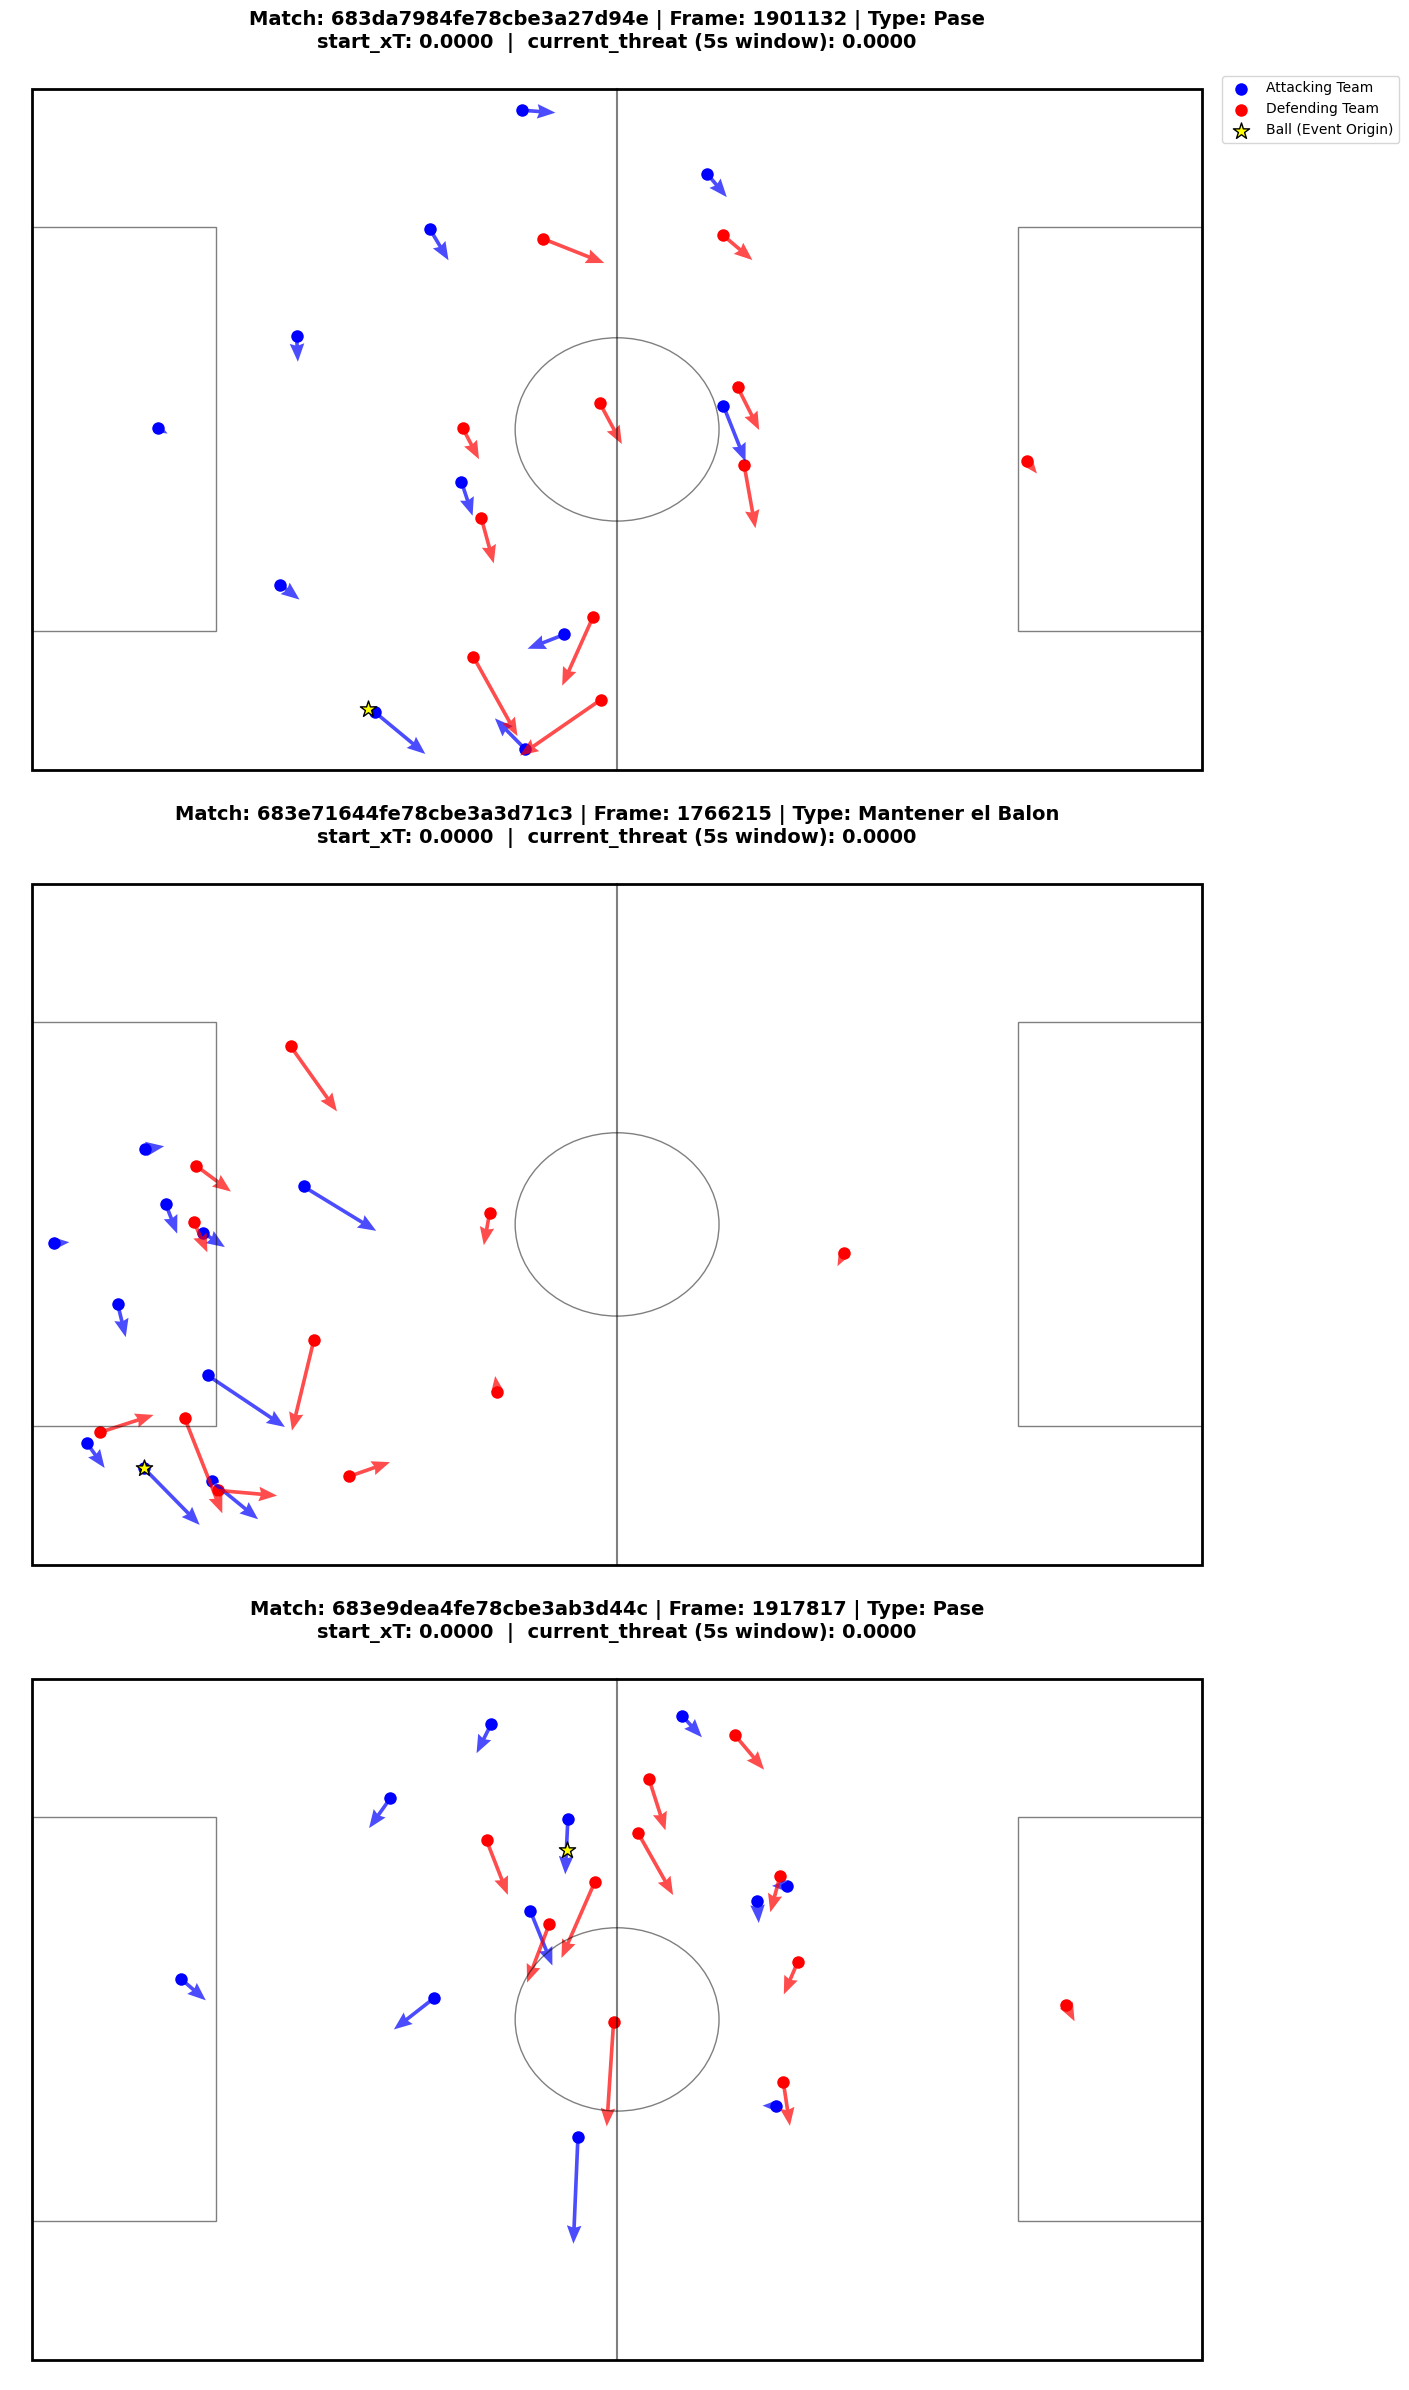

In [8]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import json

# ==============================================================================
# 1. 标准化球场绘制函数
# ==============================================================================
def draw_pitch(ax, pitch_length=105.0, pitch_width=68.0):
    """在指定的 Axes 上绘制标准的足球场底线"""
    # 草皮底色设为透明或淡色，以免干扰我们的战术空间网格
    rect = patches.Rectangle((0, 0), pitch_length, pitch_width, linewidth=2, edgecolor='black', facecolor='none', zorder=10)
    ax.add_patch(rect)
    
    # 中线与中圈
    ax.plot([pitch_length/2, pitch_length/2], [0, pitch_width], color='black', zorder=10, alpha=0.5)
    center_circle = patches.Circle((pitch_length/2, pitch_width/2), 9.15, color='black', fill=False, zorder=10, alpha=0.5)
    ax.add_patch(center_circle)
    
    # 禁区 (简化版)
    ax.add_patch(patches.Rectangle((0, pitch_width/2 - 20.16), 16.5, 40.32, fill=False, color='black', zorder=10, alpha=0.5))
    ax.add_patch(patches.Rectangle((pitch_length - 16.5, pitch_width/2 - 20.16), 16.5, 40.32, fill=False, color='black', zorder=10, alpha=0.5))
    return ax

# ==============================================================================
# 2. 数据解析安全包装器
# ==============================================================================
def safe_parse_array(val):
    if val is None: return []
    if isinstance(val, bytes):
        return json.loads(val.decode('utf-8'))
    elif isinstance(val, str):
        return json.loads(val)
    return val

# ==============================================================================
# 3. 核心可视化函数
# ==============================================================================
def plot_tactical_events(df_source, num_events=3):
    # 为了展示效果，我们优先抽取 current_threat 较高，且不为空的事件
    # 这样抽出来的战术场景更具分析价值（例如关键传球或进攻推进）
    try:
        sample_df = df_source.filter(pl.col("current_threat").is_not_null() & (pl.col("current_threat") > 0.01)) \
                             .sample(n=num_events, seed=42)
    except Exception:
        # 如果过滤条件太严苛没数据，就纯随机抽
        sample_df = df_source.sample(n=num_events, seed=42)
    
    # 转换为 Python 字典列表以方便逐行解析
    events = sample_df.to_dicts()
    
    # 定义四个战术纵深空间的渐变色 (从后场深色到前场浅色，或反之)
    cmap = ListedColormap(['#d9d9d9', '#bdbdbd', '#969696', '#636363'])
    
    fig, axes = plt.subplots(num_events, 1, figsize=(14, 8 * num_events))
    if num_events == 1: axes = [axes]
    
    for i, event in enumerate(events):
        ax = axes[i]
        draw_pitch(ax)
        
        # --- 1. 还原并绘制 1D K-Means 战术空间底图 ---
        space_list = event.get("dense_def_longitudinal_space", [])
        if space_list and len(space_list) == 7140:
            space_matrix = np.array(space_list).reshape(68, 105)
            # 使用 pcolormesh 铺满球场，alpha=0.5 防止遮挡球员
            x_bins, y_bins = np.arange(106), np.arange(69)
            ax.pcolormesh(x_bins, y_bins, space_matrix, cmap=cmap, shading='auto', alpha=0.4, zorder=1)
            
        # --- 2. 解析坐标与速度 ---
        px = safe_parse_array(event.get("stat_posx_array"))
        py = safe_parse_array(event.get("stat_posy_array"))
        vx = safe_parse_array(event.get("stat_velx_array"))
        vy = safe_parse_array(event.get("stat_vely_array"))
        is_team = safe_parse_array(event.get("stat_possteam_array"))
        
        att_x, att_y, att_vx, att_vy = [], [], [], []
        def_x, def_y, def_vx, def_vy = [], [], [], []
        
        for j in range(len(px)):
            if px[j] is None or py[j] is None: continue
            
            x, y = px[j] * 105.0, py[j] * 68.0
            v_x = (vx[j] * 105.0) if vx[j] is not None else 0.0
            v_y = (vy[j] * 68.0)  if vy[j] is not None else 0.0
            
            if is_team[j]:
                att_x.append(x); att_y.append(y); att_vx.append(v_x); att_vy.append(v_y)
            else:
                def_x.append(x); def_y.append(y); def_vx.append(v_x); def_vy.append(v_y)
                
        # --- 3. 绘制球员与速度向量 (Quiver) ---
        # 进攻方 (我方): 蓝色圆点 + 蓝色箭头
        ax.scatter(att_x, att_y, c='blue', s=100, edgecolors='white', zorder=5, label='Attacking Team')
        if np.any(att_vx):
            ax.quiver(att_x, att_y, att_vx, att_vy, color='blue', scale=50, width=0.003, headwidth=4, alpha=0.7, zorder=6)
            
        # 防守方 (敌方): 红色圆点 + 红色箭头
        ax.scatter(def_x, def_y, c='red', s=100, edgecolors='white', zorder=5, label='Defending Team')
        if np.any(def_vx):
            ax.quiver(def_x, def_y, def_vx, def_vy, color='red', scale=50, width=0.003, headwidth=4, alpha=0.7, zorder=6)
            
        # --- 4. 绘制球的位置 ---
        bx_norm, by_norm = event.get("norm_origin_pos_x"), event.get("norm_origin_pos_y")
        if bx_norm is not None and not np.isnan(bx_norm):
            bx, by = bx_norm * 105.0, by_norm * 68.0
            ax.scatter(bx, by, c='yellow', s=150, edgecolors='black', marker='*', zorder=8, label='Ball (Event Origin)')

        # --- 5. 信息文本图层 (xT & Current Threat) ---
        start_xt = event.get("start_xT", 0.0)
        curr_threat = event.get("current_threat", 0.0)
        match_id = event.get("match_id", "Unknown")
        event_type = event.get("event_type", "Unknown")
        frame = event.get("start_frame", "Unknown")
        
        title_text = (f"Match: {match_id} | Frame: {frame} | Type: {event_type}\n"
                      f"start_xT: {start_xt:.4f}  |  current_threat (5s window): {curr_threat:.4f}")
        ax.set_title(title_text, fontsize=14, fontweight='bold', pad=15)
        
        # 补充图例和限制
        ax.set_xlim(-2, 107)
        ax.set_ylim(-2, 70)
        ax.axis('off') # 关闭多余的坐标轴，让画面更干净
        if i == 0: ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))
        
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 4. 执行画图
# ==============================================================================
# 注意：传入你之前算好所有特征的 df
print("🎨 正在渲染 3 个高威胁事件的时空战术图...")
plot_tactical_events(df, num_events=3)

🔥 正在渲染 Pitch Control 稠密网格热力图...


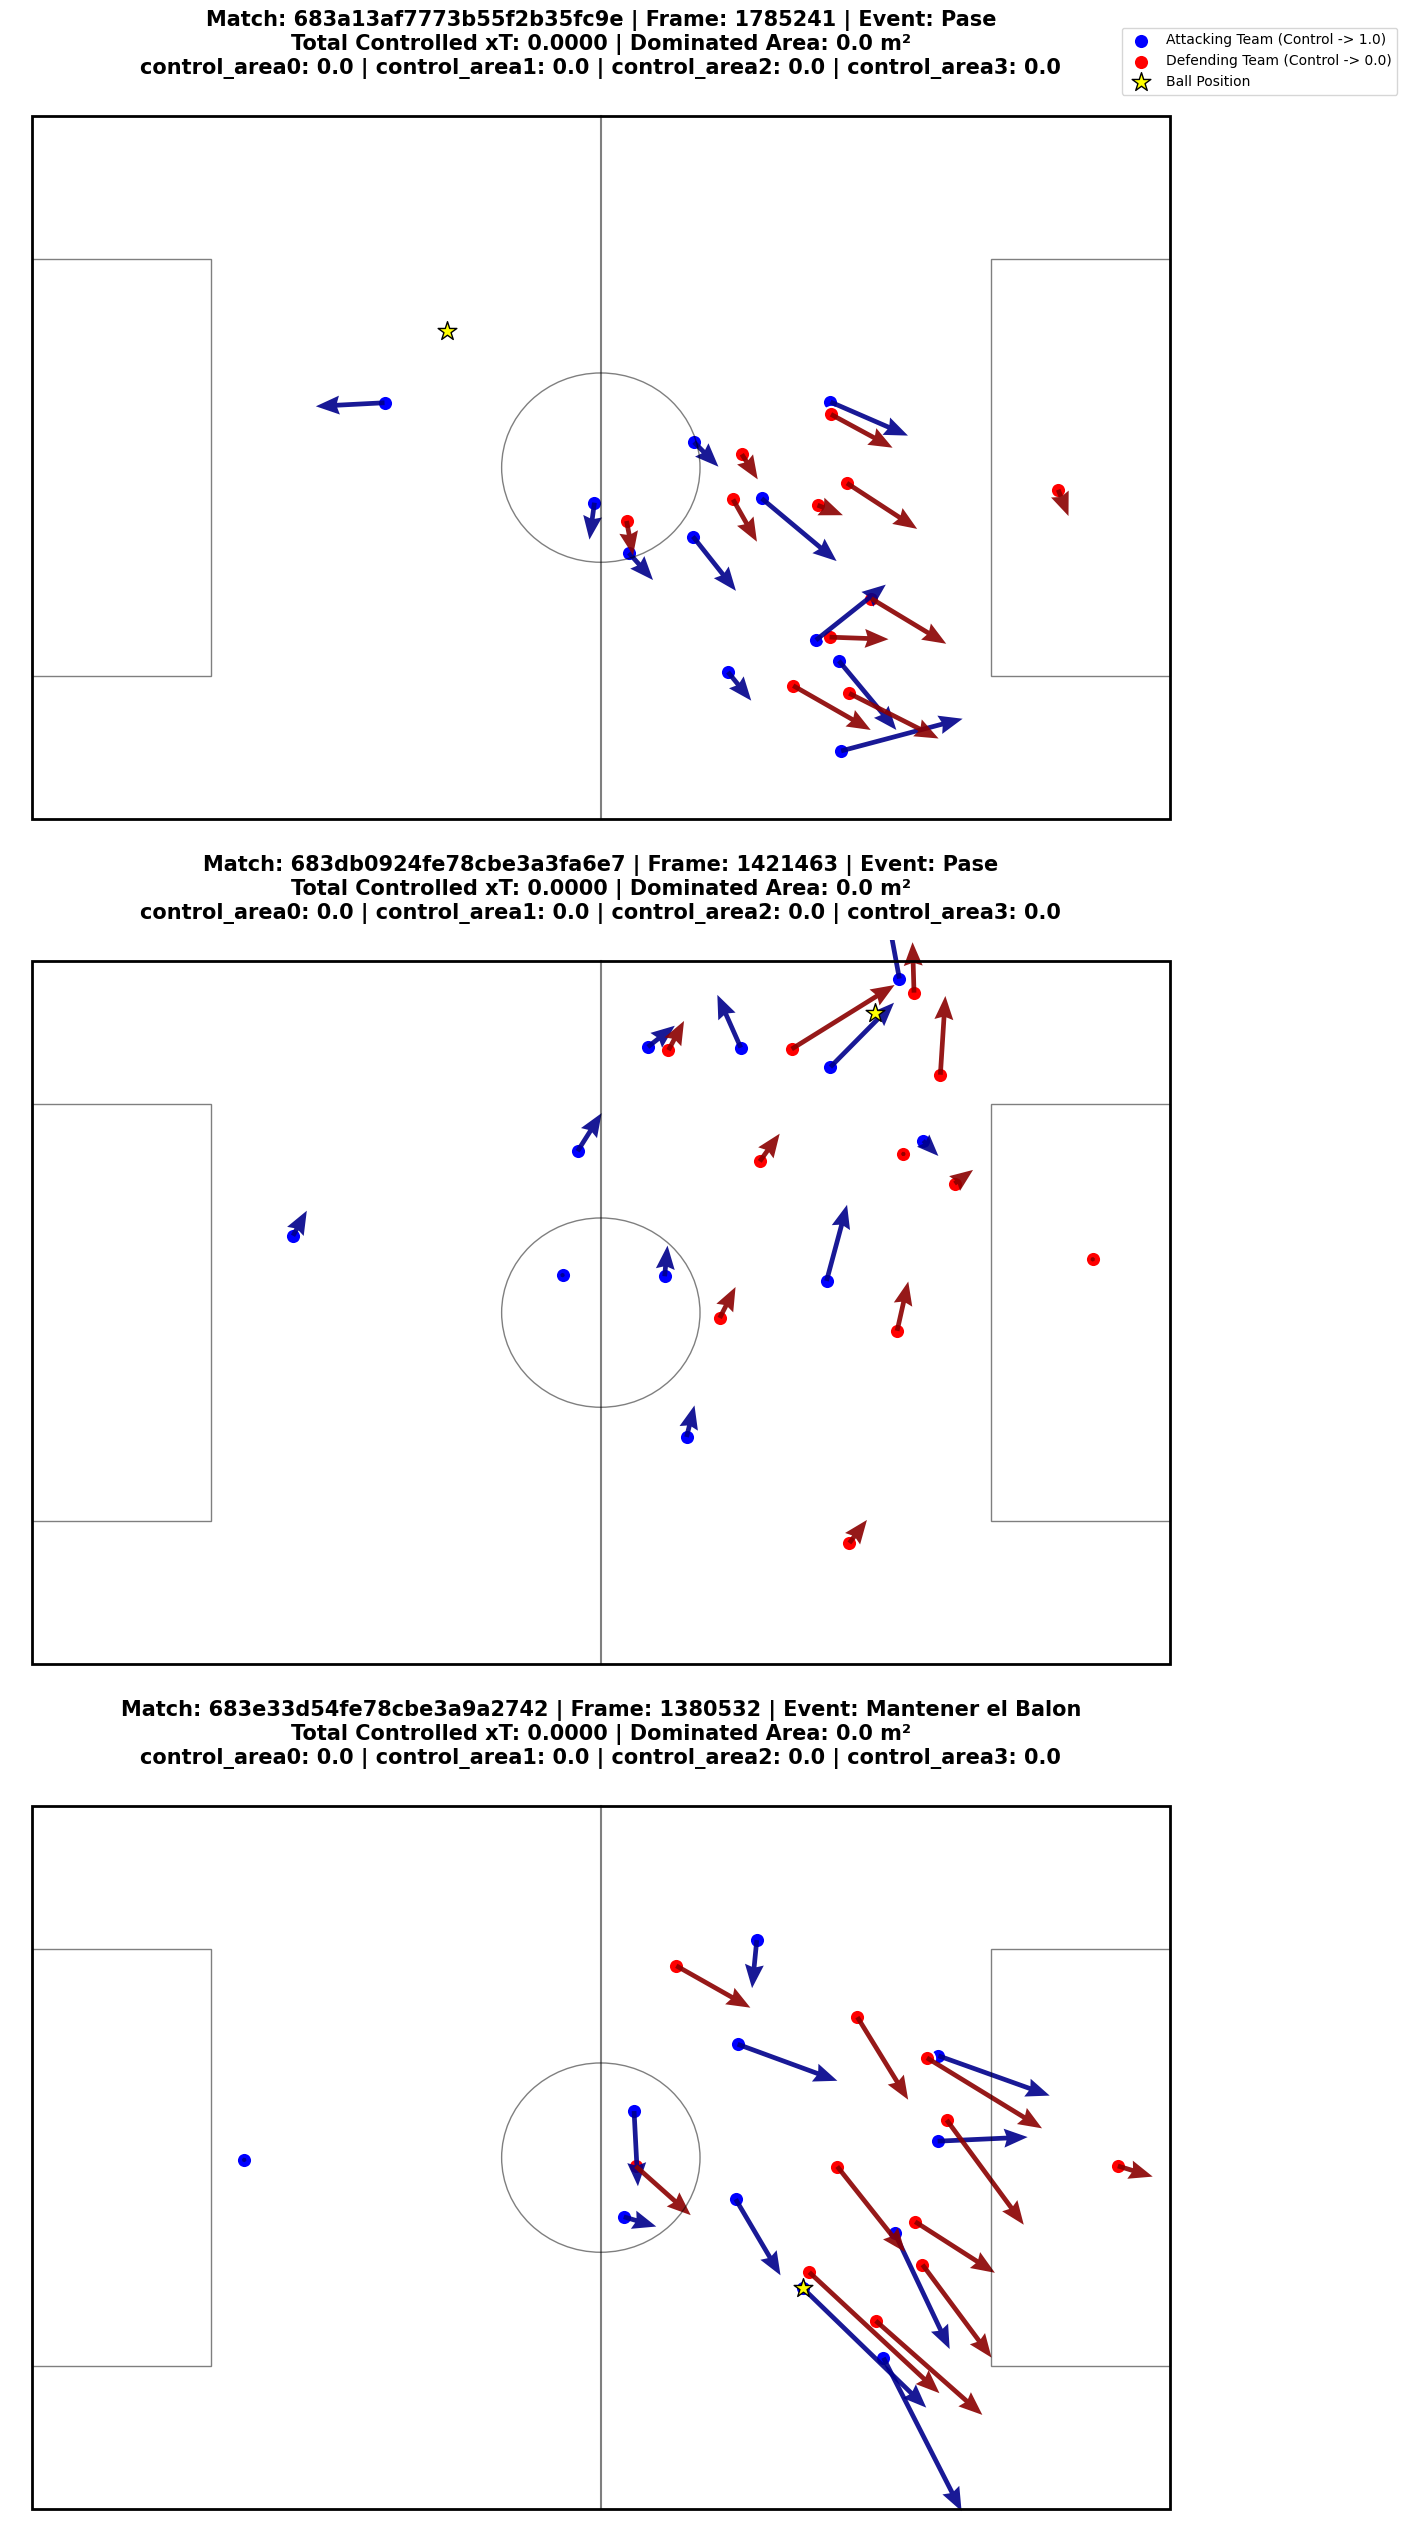

In [9]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json

# ==============================================================================
# 1. 标准化球场绘制函数
# ==============================================================================
def draw_pitch(ax, pitch_length=105.0, pitch_width=68.0):
    """在指定的 Axes 上绘制标准的足球场底线"""
    rect = patches.Rectangle((0, 0), pitch_length, pitch_width, linewidth=2, edgecolor='black', facecolor='none', zorder=10)
    ax.add_patch(rect)
    
    # 中线与中圈
    ax.plot([pitch_length/2, pitch_length/2], [0, pitch_width], color='black', zorder=10, alpha=0.5)
    center_circle = patches.Circle((pitch_length/2, pitch_width/2), 9.15, color='black', fill=False, zorder=10, alpha=0.5)
    ax.add_patch(center_circle)
    
    # 禁区
    ax.add_patch(patches.Rectangle((0, pitch_width/2 - 20.16), 16.5, 40.32, fill=False, color='black', zorder=10, alpha=0.5))
    ax.add_patch(patches.Rectangle((pitch_length - 16.5, pitch_width/2 - 20.16), 16.5, 40.32, fill=False, color='black', zorder=10, alpha=0.5))
    return ax

# ==============================================================================
# 2. 数据解析安全包装器
# ==============================================================================
def safe_parse_array(val):
    if val is None: return []
    if isinstance(val, bytes):
        return json.loads(val.decode('utf-8'))
    elif isinstance(val, str):
        return json.loads(val)
    return val

# ==============================================================================
# 3. 核心可视化函数：Pitch Control 动态热力图
# ==============================================================================
def plot_pc_heatmap_events(df_source, num_events=3):
    # 优先抽取威胁值较高的事件，这样的 PC 图表更具战术张力
    try:
        sample_df = df_source.filter(pl.col("current_threat").is_not_null() & (pl.col("current_threat") > 0.01)) \
                             .sample(n=num_events, seed=1024)
    except Exception:
        sample_df = df_source.sample(n=num_events, seed=1024)
    
    events = sample_df.to_dicts()
    
    fig, axes = plt.subplots(num_events, 1, figsize=(14, 8.5 * num_events))
    if num_events == 1: axes = [axes]
    
    for i, event in enumerate(events):
        ax = axes[i]
        draw_pitch(ax)
        
        # --- 1. 还原并绘制 1x1 米的 Pitch Control 热力图 ---
        pc_list = event.get("dense_pc_grid", [])
        if pc_list and len(pc_list) == 7140:
            # 还原为 68行 x 105列 的矩阵
            pc_matrix = np.array(pc_list).reshape(68, 105)
            
            x_bins, y_bins = np.arange(106), np.arange(69)
            # 使用 coolwarm_r: 1(我方控制)为深蓝色，0(敌方控制)为深红色，0.5为白色
            heatmap = ax.pcolormesh(x_bins, y_bins, pc_matrix, cmap='coolwarm_r', vmin=0, vmax=1, shading='auto', alpha=0.65, zorder=1)
            
            # 为每张图添加 Colorbar
            cbar = fig.colorbar(heatmap, ax=ax, fraction=0.03, pad=0.02)
            cbar.set_label('Attacking Pitch Control Probability', rotation=270, labelpad=15, fontweight='bold')
            
        # --- 2. 解析坐标与速度 ---
        px = safe_parse_array(event.get("stat_posx_array"))
        py = safe_parse_array(event.get("stat_posy_array"))
        vx = safe_parse_array(event.get("stat_velx_array"))
        vy = safe_parse_array(event.get("stat_vely_array"))
        is_team = safe_parse_array(event.get("stat_possteam_array"))
        
        att_x, att_y, att_vx, att_vy = [], [], [], []
        def_x, def_y, def_vx, def_vy = [], [], [], []
        
        for j in range(len(px)):
            if px[j] is None or py[j] is None: continue
            
            x, y = px[j] * 105.0, py[j] * 68.0
            v_x = (vx[j] * 105.0) if vx[j] is not None else 0.0
            v_y = (vy[j] * 68.0)  if vy[j] is not None else 0.0
            
            if is_team[j]:
                att_x.append(x); att_y.append(y); att_vx.append(v_x); att_vy.append(v_y)
            else:
                def_x.append(x); def_y.append(y); def_vx.append(v_x); def_vy.append(v_y)
                
        # --- 3. 绘制球员与速度向量 ---
        # 进攻方 (我方): 蓝色圆点 + 蓝色箭头 (与热力图的蓝色高值呼应)
        ax.scatter(att_x, att_y, c='blue', s=120, edgecolors='white', linewidths=1.5, zorder=5, label='Attacking Team (Control -> 1.0)')
        if np.any(att_vx):
            ax.quiver(att_x, att_y, att_vx, att_vy, color='darkblue', scale=40, width=0.004, headwidth=4, alpha=0.9, zorder=6)
            
        # 防守方 (敌方): 红色圆点 + 红色箭头 (与热力图的红色低值呼应)
        ax.scatter(def_x, def_y, c='red', s=120, edgecolors='white', linewidths=1.5, zorder=5, label='Defending Team (Control -> 0.0)')
        if np.any(def_vx):
            ax.quiver(def_x, def_y, def_vx, def_vy, color='darkred', scale=40, width=0.004, headwidth=4, alpha=0.9, zorder=6)
            
        # --- 4. 绘制球的位置 ---
        bx_norm, by_norm = event.get("norm_origin_pos_x"), event.get("norm_origin_pos_y")
        if bx_norm is not None and not np.isnan(bx_norm):
            bx, by = bx_norm * 105.0, by_norm * 68.0
            ax.scatter(bx, by, c='yellow', s=200, edgecolors='black', marker='*', zorder=8, label='Ball Position')

        # --- 5. 信息文本图层 ---
        total_xt = event.get("total_controlled_xt", 0.0)
        dom_area = event.get("dominated_area_sqm", 0.0)
        match_id = event.get("match_id", "Unknown")
        event_type = event.get("event_type", "Unknown")
        frame = event.get("start_frame", "Unknown")
        control_area0 = event.get("pc_in_def_space_0", 0.0)
        control_area1 = event.get("pc_in_def_space_1", 0.0)
        control_area2 = event.get("pc_in_def_space_2", 0.0)
        control_area3 = event.get("pc_in_def_space_3", 0.0)

        
        title_text = (f"Match: {match_id} | Frame: {frame} | Event: {event_type}\n"
                      f"Total Controlled xT: {total_xt:.4f} | Dominated Area: {dom_area} m²\n"
                      # 修复后的写法：将所有内容放在一对双引号内，内部的 {} 用于解析变量
                      f"control_area0: {control_area0} | control_area1: {control_area1} | control_area2: {control_area2} | control_area3: {control_area3}")
        ax.set_title(title_text, fontsize=15, fontweight='bold', pad=15)
        
        ax.set_xlim(-2, 107)
        ax.set_ylim(-2, 70)
        ax.axis('off') 
        if i == 0: ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1.1))
        
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 4. 执行画图
# ==============================================================================
print("🔥 正在渲染 Pitch Control 稠密网格热力图...")
plot_pc_heatmap_events(df, num_events=3)